In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ml tools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# dl tools
# Sequential model to initialize our ANN and Dense module to build the layers
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Data loading

In [3]:
churn_data = pd.read_csv('03_Churn_Modelling.csv')

In [4]:
churn_data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
churn_data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [7]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
churn_data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
churn_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
# some columns are totally unproductive so lets remove them
churn_data.drop(['CustomerId','Surname'],axis=1,inplace=True)

In [11]:
churn_data.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
churn_data.duplicated().sum()

np.int64(0)

# Encoding

In [13]:
churn_data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [14]:
churn_data['Geography']= churn_data['Geography'].map({'France':0,'Germany':1,'Spain':2})
churn_data['Gender'] = churn_data['Gender'].map({'Female':0,'Male':1})

In [15]:
churn_data_encoded = churn_data

In [16]:
churn_data_encoded

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,9997,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,9998,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,9999,772,1,1,42,3,75075.31,2,1,0,92888.52,1


# EDA

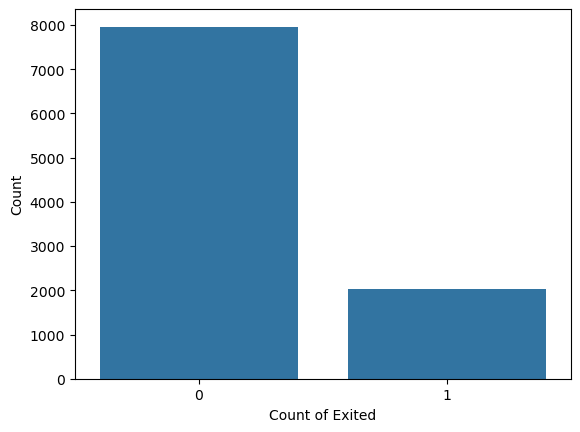

In [17]:
sns.countplot(x=churn_data_encoded['Exited'])
plt.xlabel('Count of Exited')
plt.ylabel('Count')
plt.show()

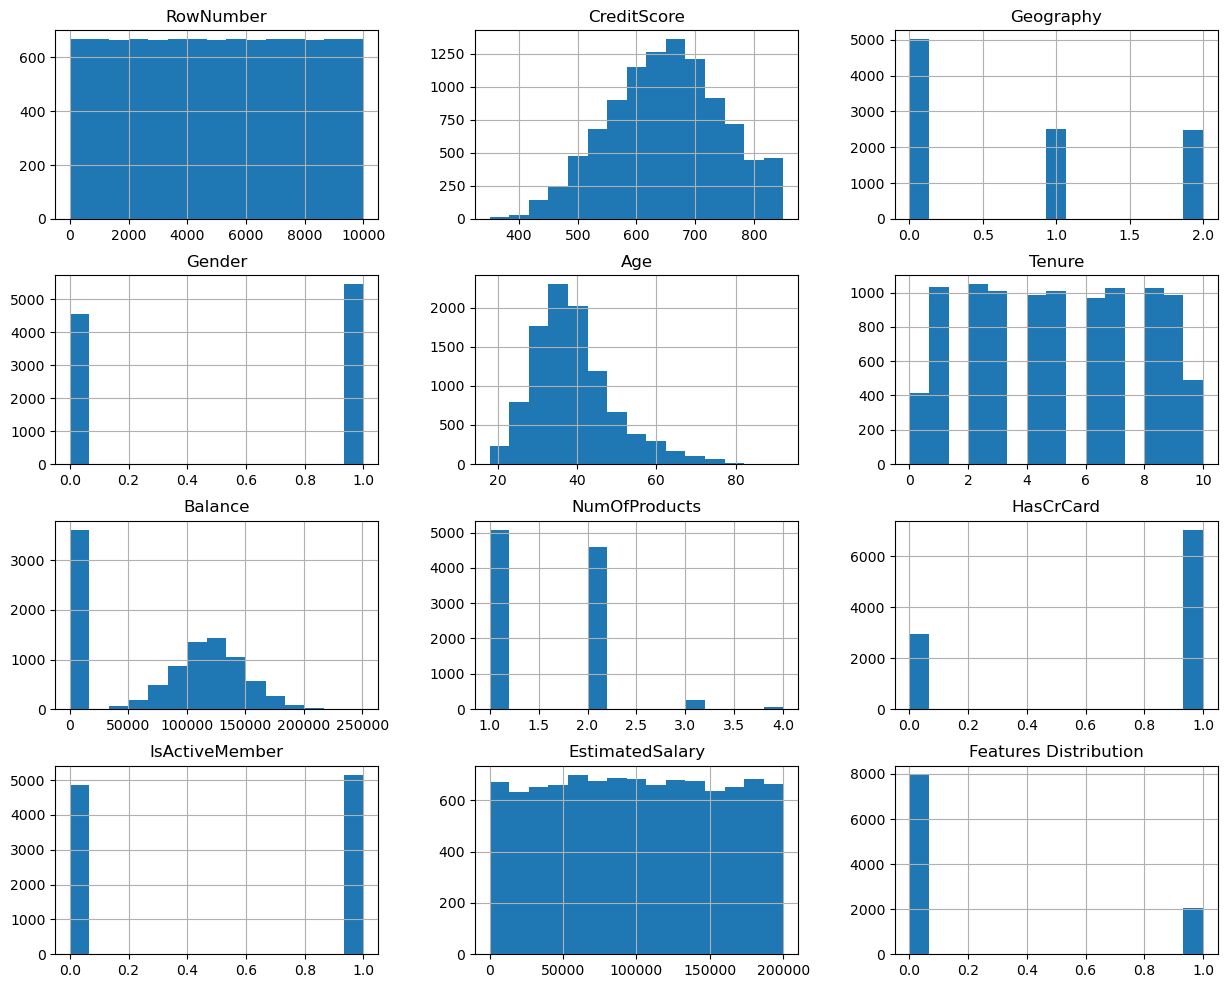

In [18]:
# distribution of all features
churn_data_encoded.hist(figsize=(15,12), bins=15)
plt.title("Features Distribution")
plt.show()

<Axes: >

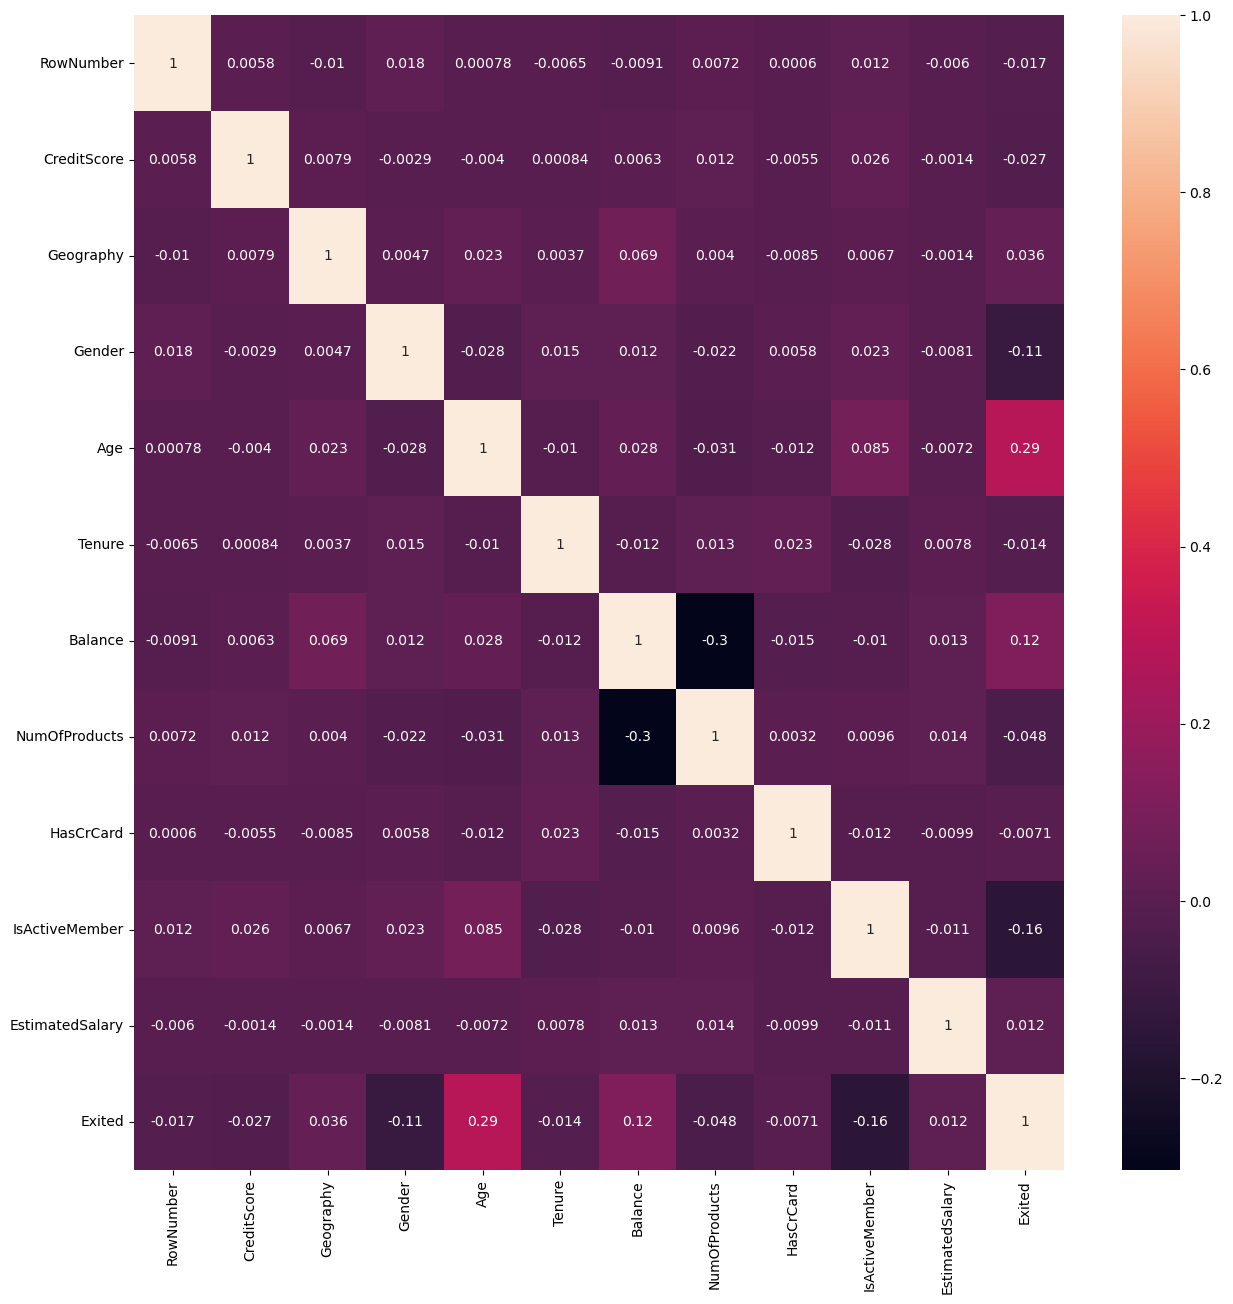

In [19]:
plt.figure(figsize=(15,15))
sns.heatmap(churn_data_encoded.corr(), annot=True)

# Train test split

In [20]:
x = churn_data_encoded.drop(['Exited'], axis=1)
y = churn_data_encoded.Exited

In [21]:
x.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1,619,0,0,42,2,0.00,1,1,1,101348.88
1,2,608,2,0,41,1,83807.86,1,0,1,112542.58
2,3,502,0,0,42,8,159660.80,3,1,0,113931.57
3,4,699,0,0,39,1,0.00,2,0,0,93826.63
4,5,850,2,0,43,2,125510.82,1,1,1,79084.10


In [22]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [23]:
# Splitting the dataset into the Training set and Test sets

x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state = 0)

In [24]:
# Feature scaling because yes we don't want one independent variable dominating the other and it makes computations easy
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# ANN Model For Classification

In [25]:
print(x_train.shape)

(8000, 11)


In [46]:
model = Sequential(
[
    # Adding the input layer and the first hidden layer
    Dense(units=6, kernel_initializer='uniform', activation='relu', input_shape=(x_train.shape[1],)),
    # Adding the second hidden layer
    Dense(units=6, kernel_initializer='uniform', activation='relu'),
    # Adding the output layer
    Dense(units=1, kernel_initializer='uniform', activation='sigmoid'),
]
)

C:\Users\subha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitors validation loss
    patience=5,          # Stops training after 5 epochs with no improvement
    restore_best_weights=True  # Restores the best model weights
)

In [48]:
# Compiling the ANN | means applying SGD on the whole ANN
model.compile(optimizer= 'adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model

In [51]:
# Fitting the ANN to the Training set
history = model.fit(x_train, y_train, batch_size=10, epochs=100, verbose=0)

In [53]:
history.history

{'accuracy': [0.8346250057220459,
  0.8355000019073486,
  0.8361250162124634,
  0.8355000019073486,
  0.8339999914169312,
  0.8352500200271606,
  0.8352500200271606,
  0.8353750109672546,
  0.8353750109672546,
  0.8335000276565552,
  0.8345000147819519,
  0.8346250057220459,
  0.8360000252723694,
  0.8336250185966492,
  0.8351250290870667,
  0.8352500200271606,
  0.8357499837875366,
  0.8356249928474426,
  0.8338750004768372,
  0.8357499837875366,
  0.8343750238418579,
  0.8348749876022339,
  0.8358749747276306,
  0.8346250057220459,
  0.8347499966621399,
  0.8351250290870667,
  0.8352500200271606,
  0.8356249928474426,
  0.8339999914169312,
  0.8352500200271606,
  0.8366249799728394,
  0.8355000019073486,
  0.8333749771118164,
  0.8332499861717224,
  0.8342499732971191,
  0.8348749876022339,
  0.8351250290870667,
  0.8346250057220459,
  0.8356249928474426,
  0.8360000252723694,
  0.8356249928474426,
  0.8360000252723694,
  0.8349999785423279,
  0.8345000147819519,
  0.8349999785423279

# Evaluate and prediction

In [54]:
score, acc = model.evaluate(x_train, y_train,batch_size=10)
print('Train score', score)
print('Train accuracy', acc)

800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8355 - loss: 0.3953
Train score 0.3953380286693573
Train accuracy 0.8355000019073486


In [55]:
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [56]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [57]:
from sklearn.metrics import confusion_matrix,accuracy_score

accuracy_score(y_test,y_pred)

0.8435

# Plot Accuracy

In [58]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


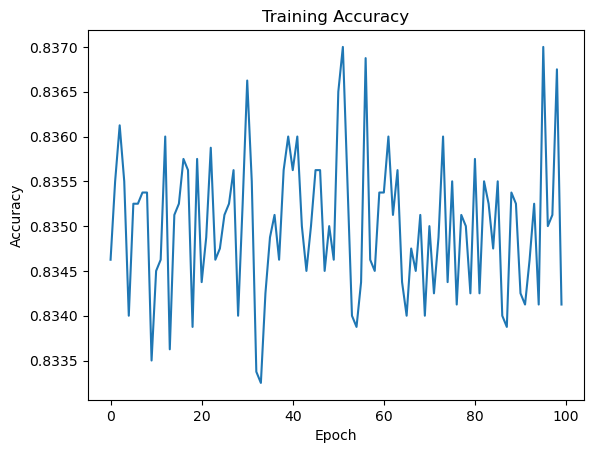

In [59]:
plt.plot(history.history['accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

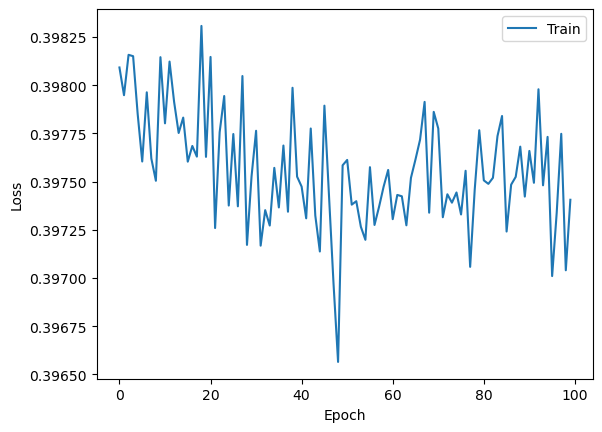

In [60]:
plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

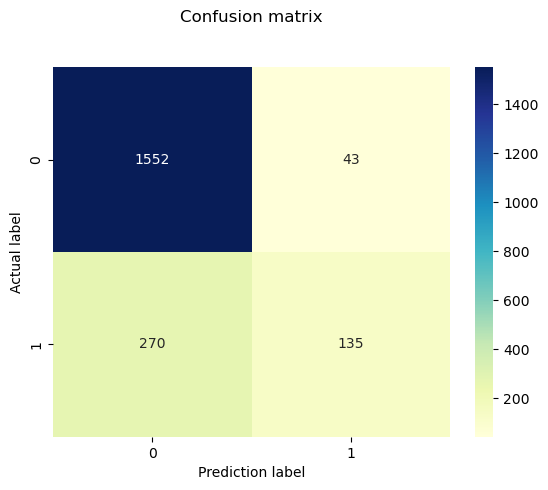

In [61]:
cm = confusion_matrix(y_test, y_pred)
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='YlGnBu', fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Prediction label')
plt.show()

In [62]:
# import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1595
           1       0.76      0.33      0.46       405

    accuracy                           0.84      2000
   macro avg       0.81      0.65      0.69      2000
weighted avg       0.83      0.84      0.82      2000



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


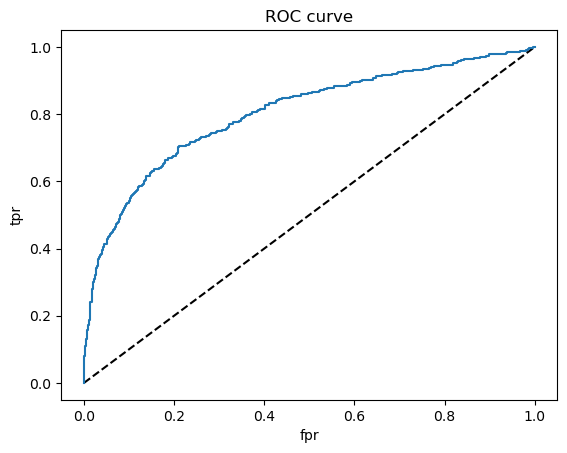

In [63]:
from sklearn.metrics import roc_curve

# Predict probabilities using the model
y_pred_proba = model.predict(x_test)

# Assuming y_test is binary (0 and 1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.show()